# Trajectory cosine similarity vs. per-component cosine similarity

We have $n$ vector-valued trajectories in time. Trial $k$ is a matrix

$$X^{(k)} \in \mathbb{R}^{T \times D},\qquad X^{(k)}_{t,d} = \text{component } d \text{ at time } t.$$

**Question.** For a pair of trials $a,b$, is the cosine similarity *between the whole trajectories* related to the cosine similarities *of each component's time-course, taken between trials*?

We define, for a pair $(a,b)$ with matrices $A=X^{(a)},\,B=X^{(b)}$:

- **Trajectory cosine** (flatten the $T\times D$ matrix; equivalently Frobenius):
$$S_{\text{traj}} = \frac{\langle A,B\rangle_F}{\|A\|_F\,\|B\|_F},\qquad \langle A,B\rangle_F = \sum_{t,d} A_{td}B_{td}.$$

- **Per-component temporal cosine** — for each component $d$, cosine of the two trials' time-courses $A_{:,d},B_{:,d}\in\mathbb{R}^{T}$:
$$c_d = \frac{\sum_t A_{td}B_{td}}{\|A_{:,d}\|\,\|B_{:,d}\|}.$$

The claim (derived below and verified numerically) is that $S_{\text{traj}}$ is an **energy-weighted average of the $c_d$**, times a **shrinkage factor** that is itself the cosine similarity of the two trials' per-component *energy profiles*.

## The identity

Let $\alpha_d = \|A_{:,d}\|$ and $\beta_d = \|B_{:,d}\|$ be the energy of component $d$ in each trial. Because the Frobenius inner product splits over components,
$$\langle A,B\rangle_F = \sum_d \alpha_d\beta_d\,c_d,\qquad \|A\|_F=\sqrt{\textstyle\sum_d\alpha_d^2},\quad \|B\|_F=\sqrt{\textstyle\sum_d\beta_d^2},$$

so

$$S_{\text{traj}} = \Big(\sum_d w_d\, c_d\Big)\times \frac{\sum_d \alpha_d\beta_d}{\sqrt{\sum_d\alpha_d^2}\sqrt{\sum_d\beta_d^2}},\qquad w_d=\frac{\alpha_d\beta_d}{\sum_{d'}\alpha_{d'}\beta_{d'}}.$$

- The first factor is a **convex ($w_d\ge0,\ \sum_d w_d=1$) average of the per-component cosines** $c_d$.
- The second factor is $\cos\angle(\alpha,\beta)$ — the **cosine similarity of the energy-profile vectors** $\alpha=(\alpha_d)_d$ and $\beta=(\beta_d)_d$. By Cauchy–Schwarz it lies in $(0,1]$, and equals $1$ iff $\alpha\propto\beta$.

Consequences:
- If the two trials spread energy across components the same way ($\alpha\propto\beta$), $S_{\text{traj}}$ **equals** the energy-weighted mean of the $c_d$.
- In general $S_{\text{traj}} \le \sum_d w_d c_d \le \max_d c_d$: mismatched energy profiles only shrink the trajectory-level similarity.
- If one component dominates the energy in both trials, $S_{\text{traj}} \approx c_{d^\*}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)


def traj_cosine(A, B):
    """Cosine similarity between two (T, D) trajectories (flattened / Frobenius)."""
    return np.sum(A * B) / (np.linalg.norm(A) * np.linalg.norm(B))


def component_cosines(A, B):
    """c_d: per-component cosine of the two trials' time-courses. Returns (D,)."""
    num = np.sum(A * B, axis=0)
    den = np.linalg.norm(A, axis=0) * np.linalg.norm(B, axis=0)
    return num / den


def decompose(A, B):
    """Return (S_traj, weighted_mean_of_c, energy_profile_cosine)."""
    alpha = np.linalg.norm(A, axis=0)          # energy per component, trial a
    beta = np.linalg.norm(B, axis=0)           # energy per component, trial b
    c = component_cosines(A, B)
    w = (alpha * beta) / np.sum(alpha * beta)  # convex weights
    weighted_mean = np.sum(w * c)
    profile_cos = np.dot(alpha, beta) / (np.linalg.norm(alpha) * np.linalg.norm(beta))
    return traj_cosine(A, B), weighted_mean, profile_cos

## Numerical verification

Make $n$ random vector-valued trajectories (with a shared low-rank bias so trials aren't orthogonal), then check the identity $S_{\text{traj}} = (\sum_d w_d c_d)\cdot\cos\angle(\alpha,\beta)$ over **every** pair.

In [2]:
T, D, n = 60, 8, 25
shared = 0.4 * rng.standard_normal((T, D))                     # common component across trials
X = [shared + rng.standard_normal((T, D)) for _ in range(n)]   # list of (T, D) trajectories

max_err = 0.0
for a in range(n):
    for b in range(n):
        S, wm, pc = decompose(X[a], X[b])
        max_err = max(max_err, abs(S - wm * pc))

print(f"n={n} trials, {n*n} pairs, T={T}, D={D}")
print(f"max |S_traj - (weighted mean of c_d) * (energy-profile cosine)| = {max_err:.2e}")
assert max_err < 1e-10
print("identity holds to machine precision.")

n=25 trials, 625 pairs, T=60, D=8
max |S_traj - (weighted mean of c_d) * (energy-profile cosine)| = 5.55e-16
identity holds to machine precision.


## Visualizing the decomposition across all trial pairs

Each point is a pair $(a,b)$: x-axis = energy-weighted mean of the per-component cosines $\sum_d w_d c_d$, y-axis = trajectory cosine $S_{\text{traj}}$. Points are colored by the energy-profile cosine $\cos\angle(\alpha,\beta)$ (the shrinkage factor). Points lie **on** the diagonal when the profile cosine is $1$ and are pulled **below** it as the profiles diverge.

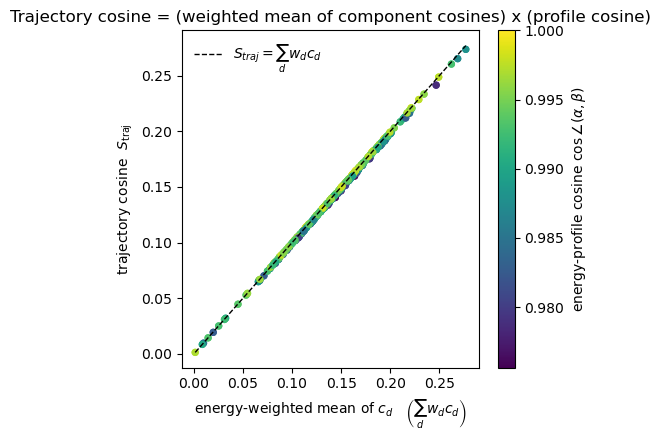

In [3]:
wm_all, S_all, pc_all = [], [], []
for a in range(n):
    for b in range(n):
        if a == b:
            continue
        S, wm, pc = decompose(X[a], X[b])
        S_all.append(S); wm_all.append(wm); pc_all.append(pc)
wm_all = np.array(wm_all); S_all = np.array(S_all); pc_all = np.array(pc_all)

fig, ax = plt.subplots(figsize=(5, 4.5))
sc = ax.scatter(wm_all, S_all, c=pc_all, cmap='viridis', s=18, vmin=pc_all.min(), vmax=1.0)
lims = [min(wm_all.min(), S_all.min()), max(wm_all.max(), S_all.max())]
ax.plot(lims, lims, 'k--', lw=1, label='$S_{traj}=\\sum_d w_d c_d$')
ax.set_xlabel(r'energy-weighted mean of $c_d$   $\left(\sum_d w_d c_d\right)$')
ax.set_ylabel(r'trajectory cosine  $S_{\mathrm{traj}}$')
cb = fig.colorbar(sc, ax=ax); cb.set_label(r'energy-profile cosine $\cos\angle(\alpha,\beta)$')
ax.legend(frameon=False)
ax.set_title('Trajectory cosine = (weighted mean of component cosines) x (profile cosine)')
fig.tight_layout()
plt.show()

## Special case: matched energy profiles $\Rightarrow$ the shrinkage factor is 1

If every trial has the *same relative energy* across components (here we force identical per-component scales), then $\alpha\propto\beta$, the profile cosine is $1$, and $S_{\text{traj}}$ equals the energy-weighted mean of the $c_d$ exactly.

In [4]:
scale = np.abs(rng.standard_normal(D)) + 0.2          # fixed energy profile shared by all trials
Y = []
for _ in range(n):
    M = rng.standard_normal((T, D))
    M = M / np.linalg.norm(M, axis=0, keepdims=True)  # unit energy per component ...
    Y.append(M * scale)                               # ... then impose the shared profile

S, wm, pc = decompose(Y[0], Y[1])
print(f"energy-profile cosine = {pc:.6f}  (=> 1)")
print(f"S_traj              = {S:.6f}")
print(f"weighted mean of c_d = {wm:.6f}")
print(f"difference           = {abs(S - wm):.2e}")

energy-profile cosine = 1.000000  (=> 1)
S_traj              = -0.021199
weighted mean of c_d = -0.021199
difference           = 6.94e-18


## Alternative slicing: by time instead of by component

The Frobenius inner product factors along *either* axis. If instead you take the cosine of the two trials' vectors **at each timepoint** (across the $D$ components) and average, the same decomposition holds with the roles of time and component swapped: weights become the per-timepoint energies $\rho_t=\|A_{t,:}\|$, and the shrinkage factor is the cosine of the two trials' energy-*over-time* profiles.

In [5]:
def decompose_timeslice(A, B):
    rho_a = np.linalg.norm(A, axis=1)         # energy per timepoint, trial a
    rho_b = np.linalg.norm(B, axis=1)
    num = np.sum(A * B, axis=1)
    c_t = num / (rho_a * rho_b)               # per-timepoint cosine across components
    w = (rho_a * rho_b) / np.sum(rho_a * rho_b)
    weighted_mean = np.sum(w * c_t)
    profile_cos = np.dot(rho_a, rho_b) / (np.linalg.norm(rho_a) * np.linalg.norm(rho_b))
    return traj_cosine(A, B), weighted_mean, profile_cos

max_err = max(
    abs((lambda r: r[0] - r[1] * r[2])(decompose_timeslice(X[a], X[b])))
    for a in range(n) for b in range(n)
)
print(f"time-slice identity max error over all pairs = {max_err:.2e}")

time-slice identity max error over all pairs = 9.99e-16


## Summary

For any pair of trials, the whole-trajectory (flattened) cosine similarity is exactly

$$S_{\text{traj}} = \underbrace{\Big(\sum_d w_d\, c_d\Big)}_{\text{energy-weighted mean of per-component cosines}}\ \times\ \underbrace{\cos\angle(\alpha,\beta)}_{\substack{\text{cosine of the two trials'}\\ \text{per-component energy profiles}}},\qquad w_d=\frac{\alpha_d\beta_d}{\sum_{d'}\alpha_{d'}\beta_{d'}}.$$

So the two notions of similarity are tightly linked: the trajectory cosine is a norm-weighted blend of the component cosines, discounted only by how differently the two trials allocate energy across components (and $\le \max_d c_d$). The same statement holds slicing by time instead of by component.